In [105]:
import os
import numpy as np
import pandas as pd
import warnings
import itertools
import random
import statsmodels.api as sm
# porphet by Facebook
from fbprophet import Prophet
# timeseries analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import ParameterGrid
# data visual
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
root_path = "."
data_path = os.path.join(root_path, "data")

# 1.read data and data information

In [102]:
df = pd.read_excel(os.path.join(data_path, "Groceries_Sales_data.xlsx"), parse_dates = [0])

## 1.1 Information of the timeseries

In [103]:
print('-'*60)
print('*** Head of the dataframe ***')
print('-'*60)
print(df.head())
print('-'*60)
print('*** Tail of the dataframe ***')
print('-'*60)
print(df.tail())
print('-'*60)
print('*** Information of the dataframe ***')
print('-'*60)
print(df.info())

------------------------------------------------------------
*** Head of the dataframe ***
------------------------------------------------------------
        Date    Sales
0 2018-02-01  21199.0
1 2018-02-02  10634.0
2 2018-02-03   7966.0
3 2018-02-04   1353.0
4 2018-02-05   9497.0
------------------------------------------------------------
*** Tail of the dataframe ***
------------------------------------------------------------
          Date    Sales
751 2020-02-22  18723.1
752 2020-02-23   4274.9
753 2020-02-24  45805.7
754 2020-02-25  35566.3
755 2020-02-26  46703.0
------------------------------------------------------------
*** Information of the dataframe ***
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    756 non-null    datetime64[ns]
 1   Sales   756 non-null

## 1.2 Plot the timeseries data

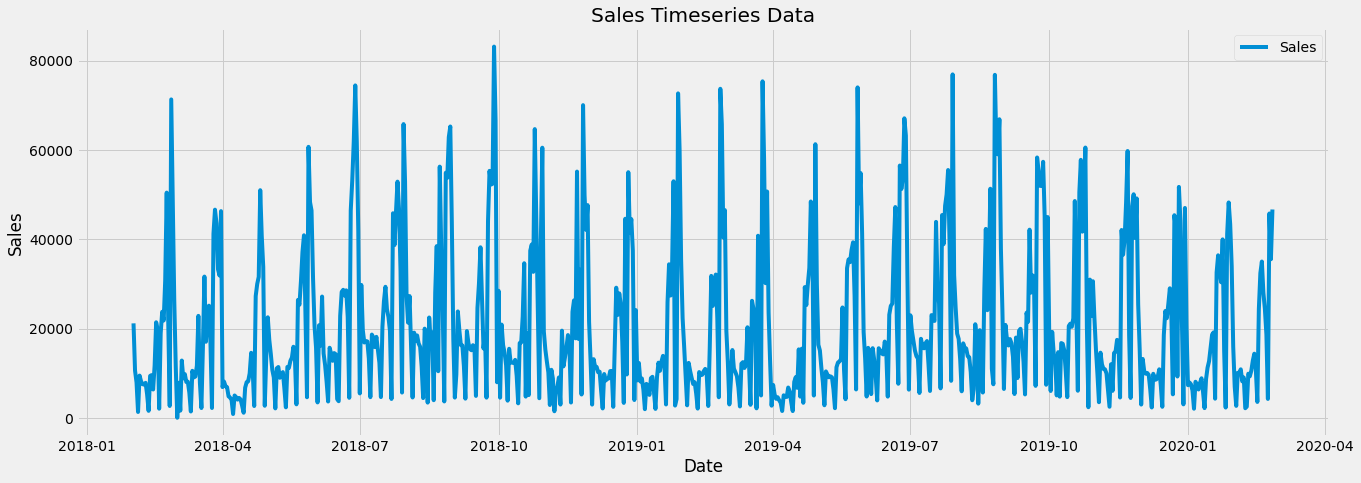

In [77]:
def timeseries_plot(df, x, y):
    fig, ax = plt.subplots(figsize = (20, 7))
    chart = sns.lineplot(x = x, y = y, data = df, label = y)
    chart.set_title("%s Timeseries Data" % y)
    plt.legend()
    plt.show()

timeseries_plot(df, "Date", "Sales")

# 2.Exploratory Data Analysis

## 2.1 Generate Date features and Exploratory

In [78]:
def date_features(df, dt, label = None):
    df = df.copy()
    df["date"] = df[dt]
    df["year"] = df["date"].dt.strftime("%Y")
    df["quarter"] = df["date"].dt.quarter
    df["month"] = df["date"].dt.strftime("%B")
    df["dayofyear"] = df["date"].dt.dayofyear
    df["dayofmonth"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.strftime("%A")
    df["weekofyear"] = df["date"].dt.weekofyear
    
    X = df[[
        "year",
        "quarter",
        "month",
        "dayofyear",
        "dayofmonth",
        "dayofweek",
        "weekofyear"
    ]]
    if label:
        y = df[label]
        return X, y
    
    return X

X, y = date_features(df, dt = "Date", label = "Sales")
df_new = pd.concat([X, y], axis = 1)
df_new.head()

,year,quarter,month,dayofyear,dayofmonth,dayofweek,weekofyear,Sales
0,2018,1,February,32,1,Thursday,5,21199.0
1,2018,1,February,33,2,Friday,5,10634.0
2,2018,1,February,34,3,Saturday,5,7966.0
3,2018,1,February,35,4,Sunday,5,1353.0
4,2018,1,February,36,5,Monday,6,9497.0


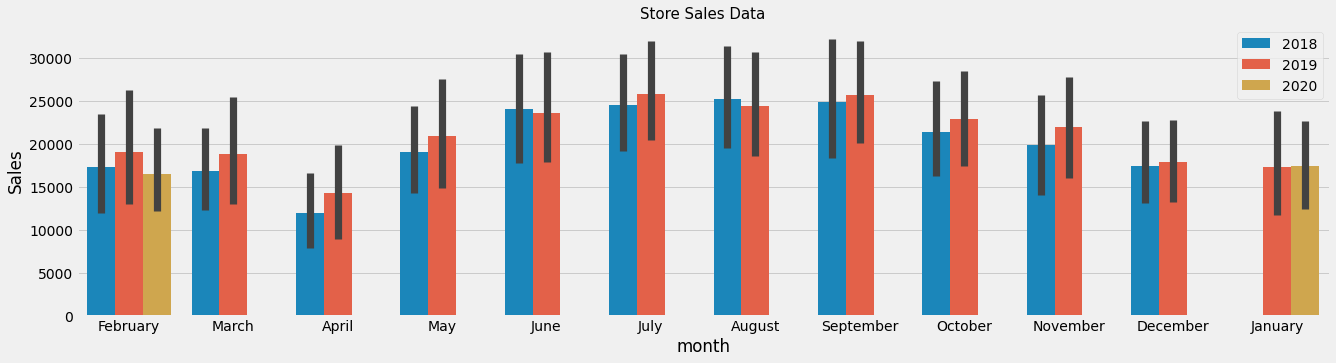

In [79]:
def bar_plot(df, x, y, categorical):
    fig, ax = plt.subplots(figsize = (20, 5))
    palette = sns.color_palette("mako_r", 4)
    a = sns.barplot(x = "month", y = "Sales", hue = "year", data = df_new)
    a.set_title("Store %s Data" % y, fontsize = 15)
    plt.legend(loc = "upper right")
    plt.show()

bar_plot(df_new, "month", "Sales", "year")

Text(0.5, 1.0, 'Total Sales received By year')

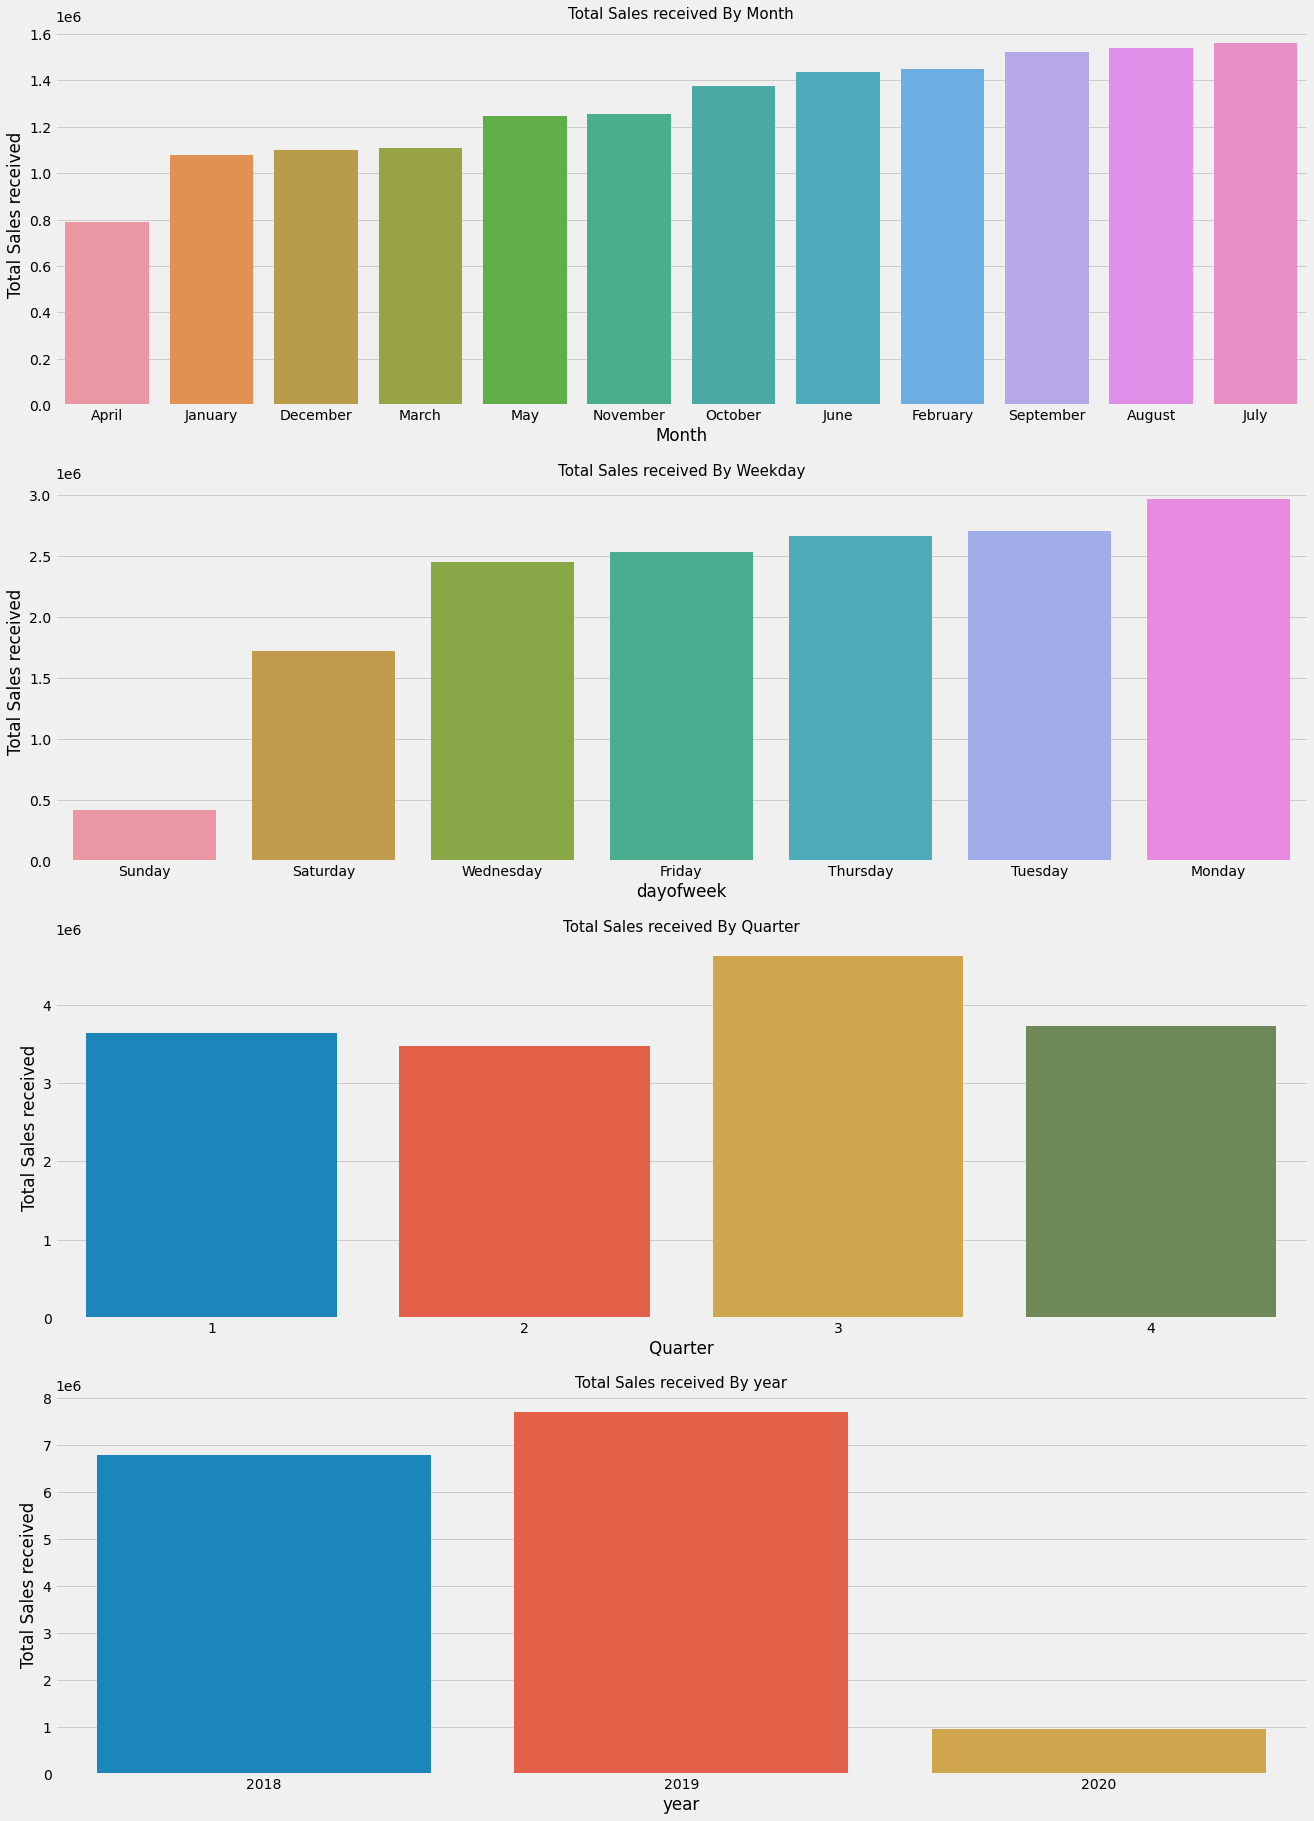

In [80]:
def bar_plots(df, x, y, xlabel, ylabel, nrows):
    fig,(ax1,ax2,ax3,ax4)= plt.subplots(nrows=nrows)
    fig.set_size_inches(20,30)
    for ax in [ax1,ax2,ax3,ax4]:
        sns.barplot(data = df, x = x,y = y, ax = ax)
        ax.set(xlabel = xlabel, ylabel = ylabel)
        ax.set_title(title, fontsize=15)


fig,(ax1,ax2,ax3,ax4)= plt.subplots(nrows=4)
fig.set_size_inches(20,30)

monthAggregated = pd.DataFrame(df_new.groupby("month")["Sales"].sum()).reset_index().sort_values('Sales')
sns.barplot(data=monthAggregated,x="month",y="Sales",ax=ax1)
ax1.set(xlabel='Month', ylabel='Total Sales received')
ax1.set_title("Total Sales received By Month",fontsize=15)

monthAggregated = pd.DataFrame(df_new.groupby("dayofweek")["Sales"].sum()).reset_index().sort_values('Sales')
sns.barplot(data=monthAggregated,x="dayofweek",y="Sales",ax=ax2)
ax2.set(xlabel='dayofweek', ylabel='Total Sales received')
ax2.set_title("Total Sales received By Weekday",fontsize=15)

monthAggregated = pd.DataFrame(df_new.groupby("quarter")["Sales"].sum()).reset_index().sort_values('Sales')
sns.barplot(data=monthAggregated,x="quarter",y="Sales",ax=ax3)
ax3.set(xlabel='Quarter', ylabel='Total Sales received')
ax3.set_title("Total Sales received By Quarter",fontsize=15)

monthAggregated = pd.DataFrame(df_new.groupby("year")["Sales"].sum()).reset_index().sort_values('Sales')
sns.barplot(data=monthAggregated,x="year",y="Sales",ax=ax4)
ax4.set(xlabel='year', ylabel='Total Sales received')
ax4.set_title("Total Sales received By year",fontsize=15)

# 3.Simple Prophet Model Training

## 3.1 Model Performance Metric

In [81]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 3.2 Split timeseries into Train and Test

In [82]:
df = df.rename(columns = {
    "Date": "ds",
    "Sales": "y"
})

end_date = "2019-12-31"
mask1 = (df["ds"] <= end_date)
mask2 = (df["ds"] > end_date)
X_train = df.loc[mask1]
X_test = df.loc[mask2]
print(X_train.shape)
print(X_test.shape)

(699, 2)
(57, 2)


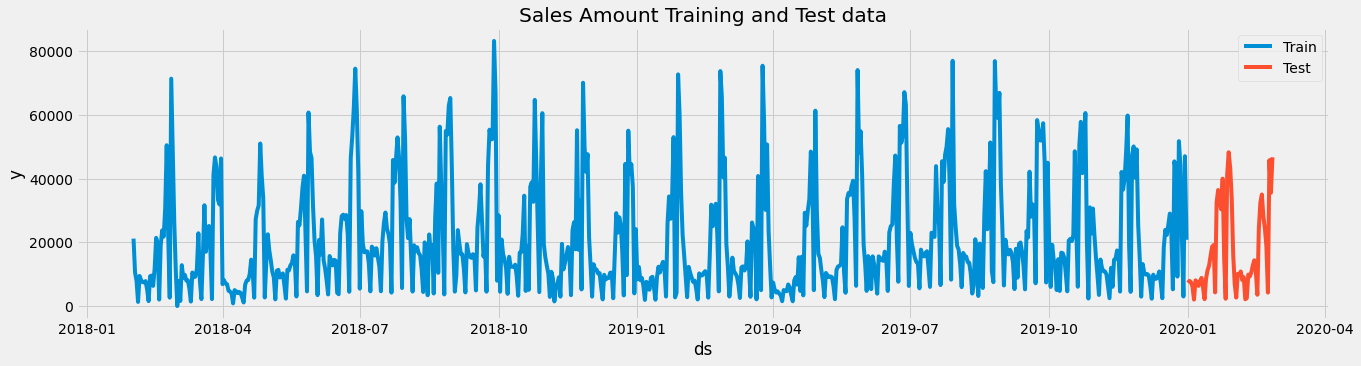

In [83]:
pd.plotting.register_matplotlib_converters()
fig, ax = plt.subplots(figsize = (20, 5))
# X_train.plot(kind = "line", x = "ds", y = "y", color = "blue", label = "Train", ax = ax)
# X_test.plot(kind = "line", x = "ds", y = "y", color = "red", label = "Test", ax = ax)
sns.lineplot(x = "ds", y = "y", data = X_train, label = "Train")
sns.lineplot(x = "ds", y = "y", data = X_test, label = "Test")
plt.title("Sales Amount Training and Test data")
plt.legend()
plt.show()

## 3.3 Simple Prophet Model

### 3.3.1 Model training on train dataset and evaluate on test dataset

In [84]:
# model training and validation
model =  Prophet()
model.fit(X_train)
future = model.make_future_dataframe(periods = 57, freq = "D")
forecast = model.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7))
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7))

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


          ds          yhat    yhat_lower    yhat_upper
0 2018-02-01  22872.820056   3749.746891  42805.518621
1 2018-02-02  21564.199631   2050.279650  40641.255301
2 2018-02-03  14032.929142  -4915.139964  34302.233159
3 2018-02-04   1628.717829 -18124.100467  20228.841416
4 2018-02-05  25488.576846   6371.326914  46532.721892
5 2018-02-06  22751.505192   3258.487873  41065.165969
6 2018-02-07  20353.423494   1661.950958  39055.984271
            ds          yhat    yhat_lower    yhat_upper
749 2020-02-20  28006.009490   7886.688994  47111.992464
750 2020-02-21  26697.381990   7750.150156  46367.318376
751 2020-02-22  19166.104428   -271.383016  39078.720145
752 2020-02-23   6761.886040 -11500.986718  25977.031382
753 2020-02-24  30621.737982  10830.194772  49689.257023
754 2020-02-25  27884.659254   7827.933610  47158.370023
755 2020-02-26  25486.570482   6649.437975  45150.729064


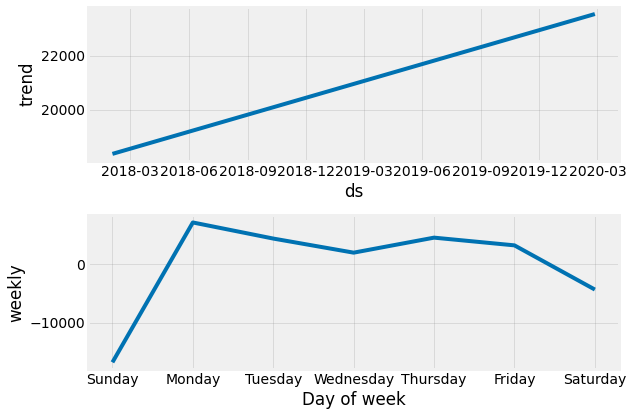

In [85]:
# Plot the components of the model
fig = model.plot_components(forecast)

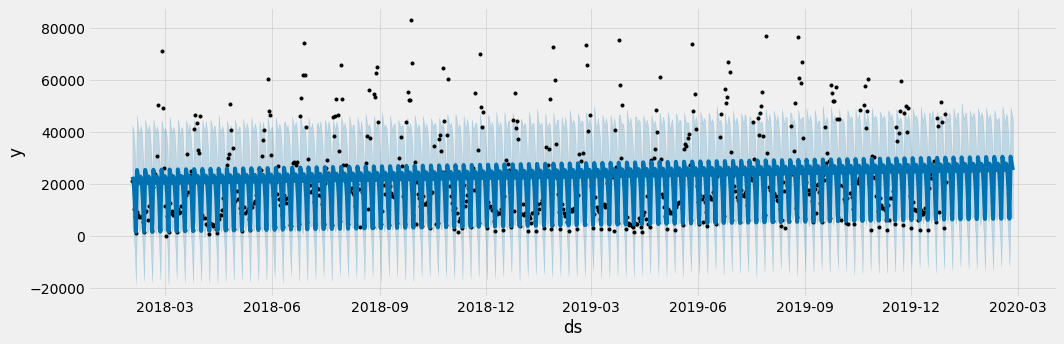

In [86]:
# plot the forecast
fig, ax = plt.subplots(1, figsize = (15, 5))
fig = model.plot(forecast, ax = ax)
plt.show()

### 3.3.2 Model performance on test dataset

In [87]:
X_test_forecast = model.predict(X_test)
print(X_test_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7))
print(X_test_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7))

          ds          yhat    yhat_lower    yhat_upper
0 2020-01-01  25102.882036   4498.898530  43448.747978
1 2020-01-02  27670.282100   8653.838911  47408.561605
2 2020-01-03  26361.654600   6670.093037  44936.687735
3 2020-01-04  18830.377038  -1295.006290  38299.146650
4 2020-01-05   6426.158650 -12096.293795  25443.288583
5 2020-01-06  30286.010592  10303.530820  48957.128302
6 2020-01-07  27548.931864   8917.112327  45858.459453
           ds          yhat    yhat_lower    yhat_upper
50 2020-02-20  28006.009490   8921.993220  47746.913353
51 2020-02-21  26697.381990   6687.995009  45978.196190
52 2020-02-22  19166.104428    138.898349  38501.784770
53 2020-02-23   6761.886040 -12892.506290  26337.751033
54 2020-02-24  30621.737982  11810.387304  50597.217916
55 2020-02-25  27884.659254   8684.754015  47315.853877
56 2020-02-26  25486.570482   6679.876397  44116.046859


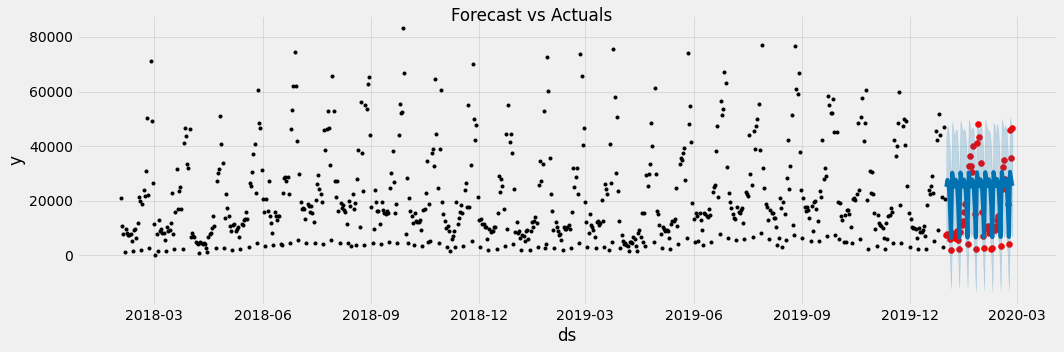

In [88]:
# plot the forecast with the actuals
fig, ax = plt.subplots(1, figsize = (15, 5))
ax.scatter(X_test["ds"], X_test["y"], color = "red")
fig = model.plot(X_test_forecast, ax = ax)
plot = plt.suptitle("Forecast vs Actuals")
plt.show()

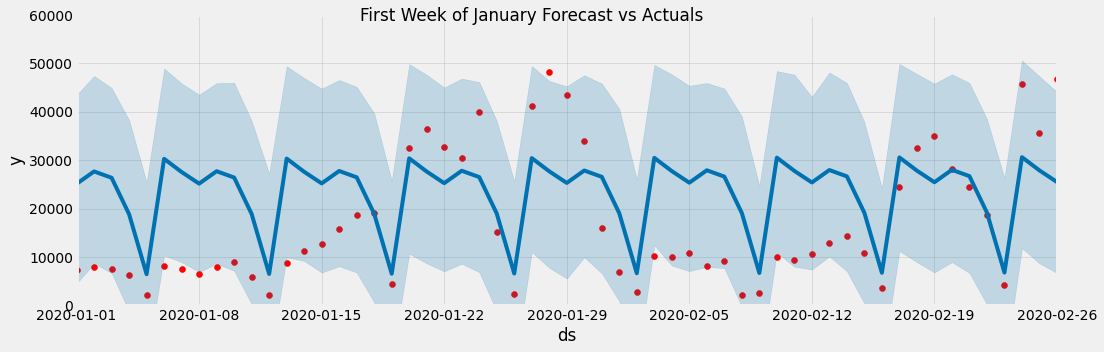

In [89]:
# Plot the forecast with the actuals of 2020
fig, ax = plt.subplots(1, figsize = (15, 5))
ax.scatter(X_test["ds"], X_test["y"], color = "red")
fig = model.plot(X_test_forecast, ax = ax)
ax.set_xbound(lower = "2020-01-01", upper = "2020-02-26")
ax.set_ylim(0, 60000)
plot = plt.suptitle("First Week of January Forecast vs Actuals")
plt.show()

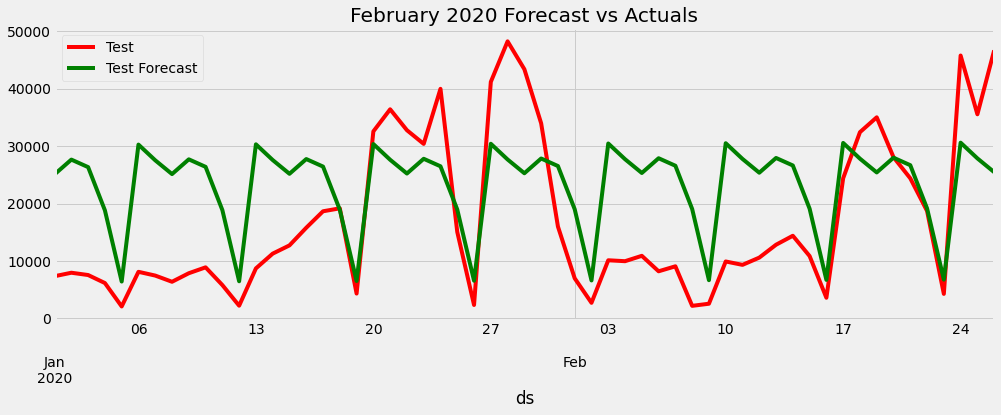

In [90]:
# Compare the Sales and forecasted Sales
fig, ax = plt.subplots(1, figsize = (15, 5))
X_test.plot(kind = "line", x = "ds", y = "y", color = "red", label = "Test", ax = ax)
X_test_forecast.plot(kind = "line", x = "ds", y = "yhat", color = "green", label = "Test Forecast", ax = ax)
plt.title("February 2020 Forecast vs Actuals")
plt.show()

In [91]:
# Model performance on X_test
mape = mean_absolute_percentage_error(X_test["y"], X_test_forecast["yhat"])
print("MAPE:%s" % round(mape, 4))

MAPE:128.9153


### 3.3.3 Adding holidays to the model

In [92]:
import holidays

holiday = pd.DataFrame([])
for date, name in sorted(holidays.UnitedStates(years = [2018, 2019, 2020]).items()):
    holiday_df = pd.DataFrame({
        "ds": date, 
        "holiday": "US-Hoildays"
    }, index = [0])
    holiday = holiday.append(holiday_df, ignore_index = True)

holiday["ds"] = pd.to_datetime(holiday["ds"], format = "%Y-%m-%d", errors = "ignore")
holiday

,ds,holiday
0,2018-01-01,US-Hoildays
1,2018-01-15,US-Hoildays
2,2018-02-19,US-Hoildays
3,2018-05-28,US-Hoildays
4,2018-07-04,US-Hoildays
5,2018-09-03,US-Hoildays
6,2018-10-08,US-Hoildays
7,2018-11-11,US-Hoildays
8,2018-11-12,US-Hoildays
9,2018-11-22,US-Hoildays


In [93]:
# Setup and train model with holidays
model_with_holidays = Prophet(holidays = holiday)
model_with_holidays.fit(X_test)
future = model_with_holidays.make_future_dataframe(periods = 57, freq = "D")
forecast = model_with_holidays.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7))
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7))

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


          ds          yhat    yhat_lower    yhat_upper
0 2020-01-01  16070.710842   2860.677544  29210.507865
1 2020-01-02  11571.994346  -1919.709081  25273.087008
2 2020-01-03  10804.086374  -2847.745512  23761.456810
3 2020-01-04   4048.834174 -10481.279394  17458.630691
4 2020-01-05  -3558.822633 -18302.238073  10449.137537
5 2020-01-06  15832.977129   1517.512607  29155.839302
6 2020-01-07  17262.095340   3748.079890  31821.987577
            ds          yhat    yhat_lower    yhat_upper
107 2020-04-17  38845.009429  25411.335834  52246.492746
108 2020-04-18  32089.717968  17485.313362  44906.284965
109 2020-04-19  24482.021900   9860.212984  38220.570219
110 2020-04-20  43873.782400  29634.728983  57907.614572
111 2020-04-21  45302.861349  31397.095190  57966.338933
112 2020-04-22  45186.082553  31233.108406  59685.677576
113 2020-04-23  41482.293173  27422.993429  55596.436382


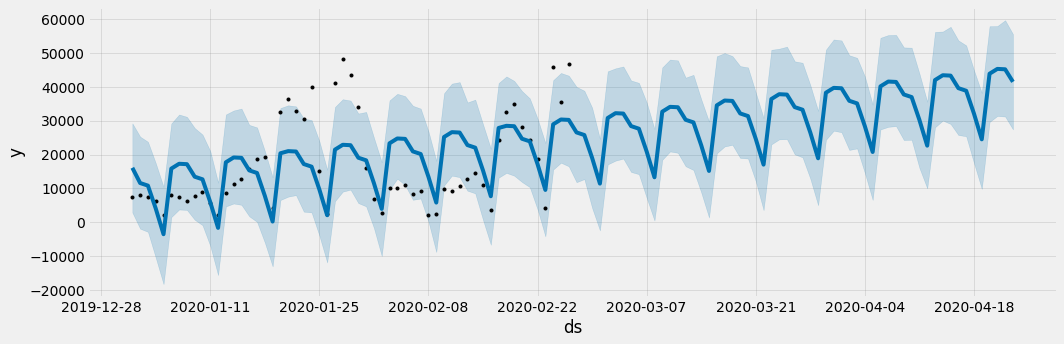

In [94]:
# plot the forecast
fig, ax = plt.subplots(1, figsize = (15, 5))
fig = model_with_holidays.plot(forecast, ax = ax)
plt.show()

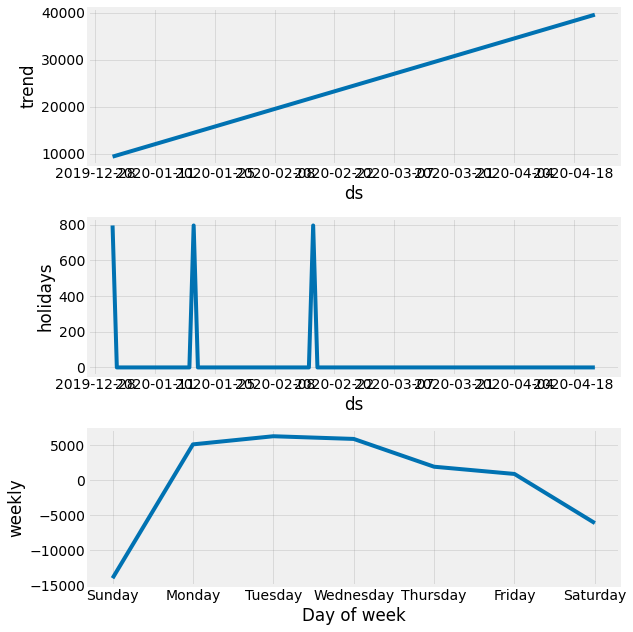

In [95]:
# Plot the components of the model
fig = model_with_holidays.plot_components(forecast)

In [96]:
X_test_forecast_holidays = model_with_holidays.predict(X_test)
print(X_test_forecast_holidays[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7))
print(X_test_forecast_holidays[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7))

          ds          yhat    yhat_lower    yhat_upper
0 2020-01-01  16070.710842   1883.118871  29244.256711
1 2020-01-02  11571.994346  -2054.221701  25477.779259
2 2020-01-03  10804.086374  -2041.282867  23966.088218
3 2020-01-04   4048.834174  -9359.412395  17892.236402
4 2020-01-05  -3558.822633 -17522.978757   9873.039597
5 2020-01-06  15832.977129   2879.334108  29191.347093
6 2020-01-07  17262.095340   2567.128788  30963.236711
           ds          yhat    yhat_lower    yhat_upper
50 2020-02-20  24658.264582   9641.018870  38280.269455
51 2020-02-21  23890.317348  10509.824786  36053.953403
52 2020-02-22  17135.025887   4702.919556  30724.685275
53 2020-02-23   9527.329818  -3852.774417  23683.267546
54 2020-02-24  28919.090319  15439.857625  42034.023503
55 2020-02-25  30348.169268  17150.398322  44485.616767
56 2020-02-26  30231.390472  15859.780757  43833.422496


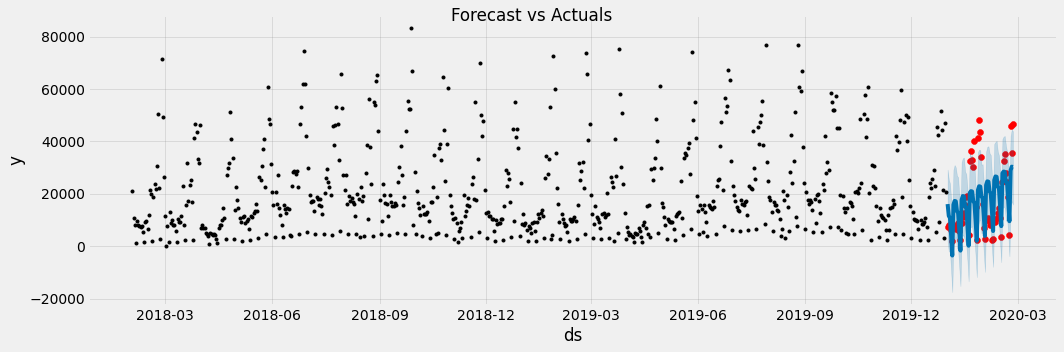

In [97]:
# plot the forecast with the actuals
fig, ax = plt.subplots(1, figsize = (15, 5))
ax.scatter(X_test["ds"], X_test["y"], color = "red")
fig = model.plot(X_test_forecast_holidays, ax = ax)
plot = plt.suptitle("Forecast vs Actuals")
plt.show()

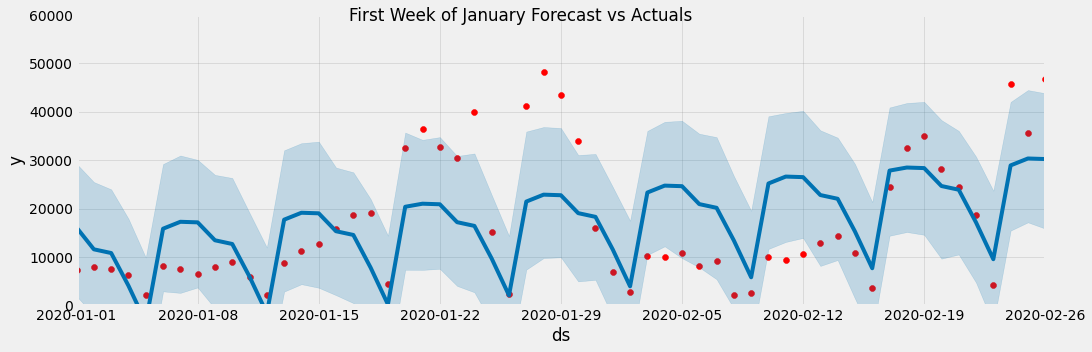

In [98]:
# Plot the forecast with the actuals of 2020
fig, ax = plt.subplots(1, figsize = (15, 5))
ax.scatter(X_test["ds"], X_test["y"], color = "red")
fig = model.plot(X_test_forecast_holidays, ax = ax)
ax.set_xbound(lower = "2020-01-01", upper = "2020-02-26")
ax.set_ylim(0, 60000)
plot = plt.suptitle("First Week of January Forecast vs Actuals")
plt.show()

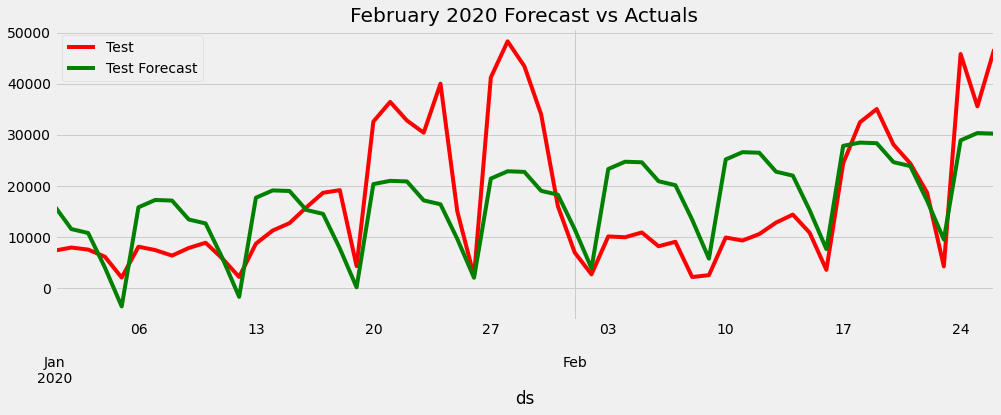

In [99]:
# Compare the Sales and forecasted Sales
fig, ax = plt.subplots(1, figsize = (15, 5))
X_test.plot(kind = "line", x = "ds", y = "y", color = "red", label = "Test", ax = ax)
X_test_forecast_holidays.plot(kind = "line", x = "ds", y = "yhat", color = "green", label = "Test Forecast", ax = ax)
plt.title("February 2020 Forecast vs Actuals")
plt.show()

In [100]:
# Model performance on X_test
mape = mean_absolute_percentage_error(X_test["y"], X_test_forecast_holidays["yhat"])
print("MAPE:%s" % round(mape, 4))

MAPE:79.8495


# 4.HyperParmeter Tuning using ParameterGrid

In [72]:
# parameters
params_grid = {
    "seasonality_mode": ("multiplicative", "additive"),
    "changepoint_prior_scale": [0.1, 0.2, 0.3, 0.4, 0.5],
    "holidays_prior_scale": [0.1, 0.2, 0.3, 0.4, 0.5],
    "n_changepoints": [100, 150, 200],
}
grid = ParameterGrid(params_grid)
cnt = np.sum([1 for p in grid])
print("Total Possible Models: %s" % cnt)

Total Possible Models: 150


## 4.1 Prophet Model Tuning

In [29]:
start = "2019-12-31"
end = "2020-02-26"

model_parameters = pd.DataFrame(columns = ["MAPE", "Parameters"])
for param in grid:
    print(param)
    random.seed(0)
    test = pd.DataFrame()
    train_model = Prophet(
        changepoint_prior_scale = param["changepoint_prior_scale"],
        holidays_prior_scale = param["holidays_prior_scale"],
        n_changepoints = param["n_changepoints"],
        seasonality_mode = param["seasonality_mode"],
        weekly_seasonality = True,
        daily_seasonality = True,
        yearly_seasonality = True,
        holidays = holiday,
        interval_width = 0.95
    )
    train_model.add_country_holidays(country_name = "US")
    train_model.fit(X_test)
    train_forecast = train_model.make_future_dataframe(periods = 57, freq = "D", include_history = False)
    train_forecast = train_model.predict(train_forecast)
    test = train_forecast[["ds", "yhat"]]
    Actual = df[(df["ds"] > start) & (df["ds"] <= end)]
    MAPE = mean_absolute_percentage_error(Actual["y"], abs(test["yhat"]))
    print("Mean Absolute Percentage Error(MAPE)%s" % ("-" * 30), MAPE)
    
    model_parameters = model_parameters.append({
        "MAPE": MAPE, 
        "Parameters": param
    }, ignore_index = True)

INFO:fbprophet:n_changepoints greater than number of observations. Using 44.


{'changepoint_prior_scale': 0.1, 'holidays_prior_scale': 0.1, 'n_changepoints': 100, 'seasonality_mode': 'multiplicative'}


INFO:fbprophet:n_changepoints greater than number of observations. Using 44.


Mean Absolute Percentage Error(MAPE)------------------------------ 16251.417429092777
{'changepoint_prior_scale': 0.1, 'holidays_prior_scale': 0.1, 'n_changepoints': 100, 'seasonality_mode': 'additive'}


INFO:fbprophet:n_changepoints greater than number of observations. Using 44.


...

Mean Absolute Percentage Error(MAPE)------------------------------ 58092.41383830342
{'changepoint_prior_scale': 0.5, 'holidays_prior_scale': 0.5, 'n_changepoints': 150, 'seasonality_mode': 'additive'}


INFO:fbprophet:n_changepoints greater than number of observations. Using 44.


Mean Absolute Percentage Error(MAPE)------------------------------ 6767.623724494458
{'changepoint_prior_scale': 0.5, 'holidays_prior_scale': 0.5, 'n_changepoints': 200, 'seasonality_mode': 'multiplicative'}


INFO:fbprophet:n_changepoints greater than number of observations. Using 44.


Mean Absolute Percentage Error(MAPE)------------------------------ 58092.41383830342
{'changepoint_prior_scale': 0.5, 'holidays_prior_scale': 0.5, 'n_changepoints': 200, 'seasonality_mode': 'additive'}
Mean Absolute Percentage Error(MAPE)------------------------------ 6767.623724494458


In [30]:
parameters = model_parameters.sort_values(by = ["MAPE"])
parameters = parameters.reset_index(drop = True)
parameters

,MAPE,Parameters
0,600.152681,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
1,600.152681,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
2,600.152681,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
3,601.121555,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
4,601.121555,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
...,...,...
145,62411.485470,"{'changepoint_prior_scale': 0.4, 'holidays_pri..."
146,62411.485470,"{'changepoint_prior_scale': 0.4, 'holidays_pri..."
147,67185.219979,"{'changepoint_prior_scale': 0.5, 'holidays_pri..."
148,67185.219979,"{'changepoint_prior_scale': 0.5, 'holidays_pri..."


### The best model

In [31]:
parameters["Parameters"][0]

{'changepoint_prior_scale': 0.2,
 'holidays_prior_scale': 0.5,
 'n_changepoints': 100,
 'seasonality_mode': 'multiplicative'}

## 4.2 Train the final model

In [38]:
# Setup and trin model with holidays
final_model = Prophet(
    holidays = holiday,
    changepoint_prior_scale = 0.5,
    holidays_prior_scale = 0.1,
    n_changepoints = 200,
    seasonality_mode = "multiplicative",
    weekly_seasonality = True,
    daily_seasonality = True,
    yearly_seasonality = True,
    interval_width = 0.95
)
final_model.add_country_holidays(country_name = "US")
final_model.fit(X_test)
future = final_model.make_future_dataframe(periods = 122, freq = "D")
forecast = final_model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7)

INFO:fbprophet:n_changepoints greater than number of observations. Using 44.


,ds,yhat,yhat_lower,yhat_upper
0,2020-01-01,7181.486988,5424.406970,9012.575530
1,2020-01-02,8369.294387,6447.402323,10150.933517
2,2020-01-03,7263.557127,5395.015526,9116.730890
3,2020-01-04,6127.789182,4279.282037,7822.198262
4,2020-01-05,1674.669249,-230.489789,3538.399324
5,2020-01-06,7889.831945,6132.789679,9788.009063
6,2020-01-07,7320.760296,5586.838797,9254.367795


In [39]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7)

,ds,yhat,yhat_lower,yhat_upper
172,2020-06-21,106841.986236,-1.274359e+06,1.571125e+06
173,2020-06-22,438138.493194,-5.263415e+06,6.471001e+06
174,2020-06-23,370783.091303,-4.470011e+06,5.490535e+06
175,2020-06-24,416402.830298,-5.038855e+06,6.160845e+06
176,2020-06-25,268550.545859,-3.271349e+06,3.971189e+06
177,2020-06-26,189635.153424,-2.326206e+06,2.801064e+06
178,2020-06-27,93775.524033,-1.161420e+06,1.390548e+06


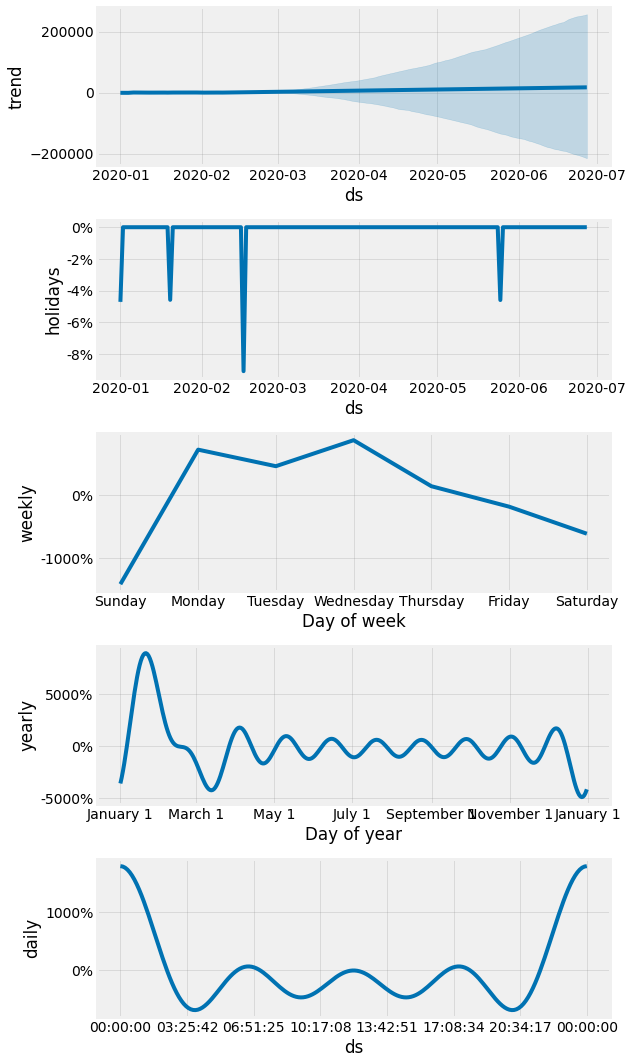

In [40]:
# plot the components of the model
fig = final_model.plot_components(forecast)

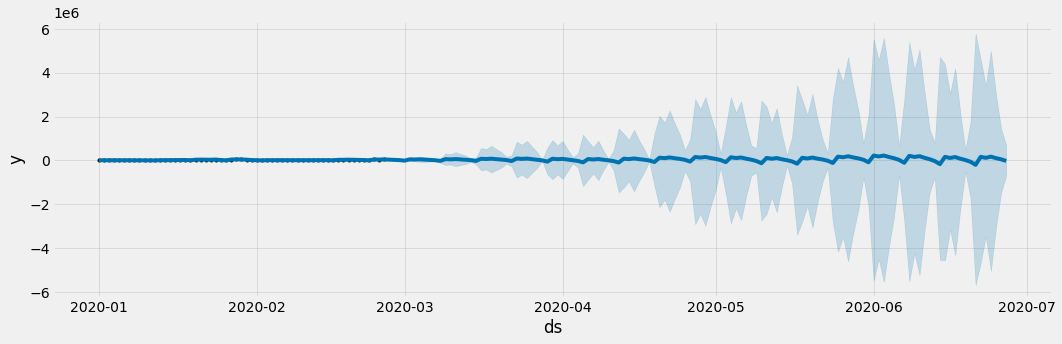

In [36]:
# plot the forecast
fig, ax = plt.subplots(1, figsize = (15, 5))
fig = final_model.plot(forecast, ax = ax)
plt.show()

In [44]:
X_test_final = final_model.predict(X_test)
X_test_final[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7)

,ds,yhat,yhat_lower,yhat_upper
0,2020-01-01,7181.486988,5264.959308,8967.045274
1,2020-01-02,8369.294387,6542.220047,10207.632679
2,2020-01-03,7263.557127,5328.858916,9101.841101
3,2020-01-04,6127.789182,4316.631158,8058.802248
4,2020-01-05,1674.669249,-289.298721,3604.052545
5,2020-01-06,7889.831945,6116.996022,9783.319864
6,2020-01-07,7320.760296,5381.069019,9293.139279


In [45]:
X_test_final[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7)

,ds,yhat,yhat_lower,yhat_upper
50,2020-02-20,28328.477632,26555.604532,30076.030980
51,2020-02-21,24977.428250,23185.304636,26843.364494
52,2020-02-22,18613.171854,16696.981499,20424.413506
53,2020-02-23,3776.043650,1912.160618,5660.056833
54,2020-02-24,43850.282489,42028.640186,45585.322157
55,2020-02-25,38274.822310,36408.518013,40128.105313
56,2020-02-26,45940.123046,44006.575918,47785.995057


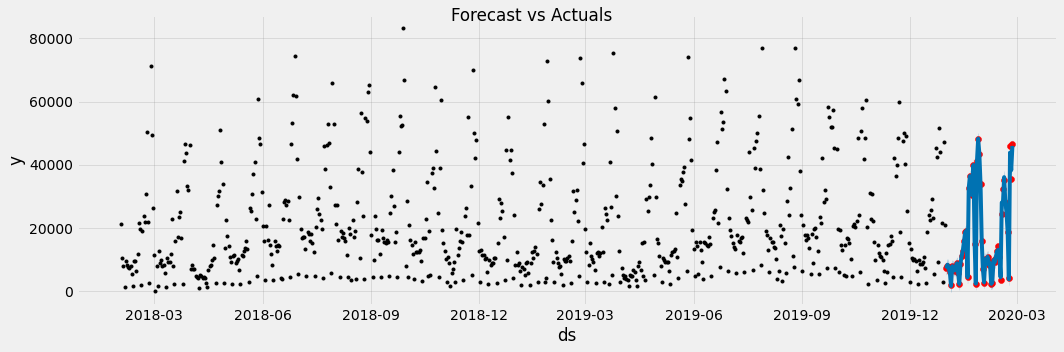

In [46]:
# plot the forecast with the actuals
fig, ax = plt.subplots(1, figsize = (15, 5))
ax.scatter(X_test["ds"], X_test["y"], color = "red")
fig = model.plot(X_test_final, ax = ax)
plot = plt.suptitle("Forecast vs Actuals")
plt.show()

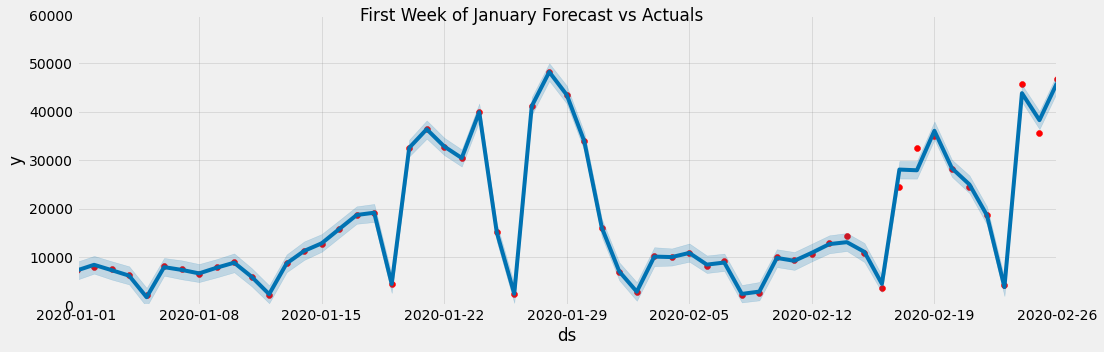

In [47]:
# Plot the forecast with the actuals of 2020
fig, ax = plt.subplots(1, figsize = (15, 5))
ax.scatter(X_test["ds"], X_test["y"], color = "red")
fig = model.plot(X_test_final, ax = ax)
ax.set_xbound(lower = "2020-01-01", upper = "2020-02-26")
ax.set_ylim(0, 60000)
plot = plt.suptitle("First Week of January Forecast vs Actuals")
plt.show()

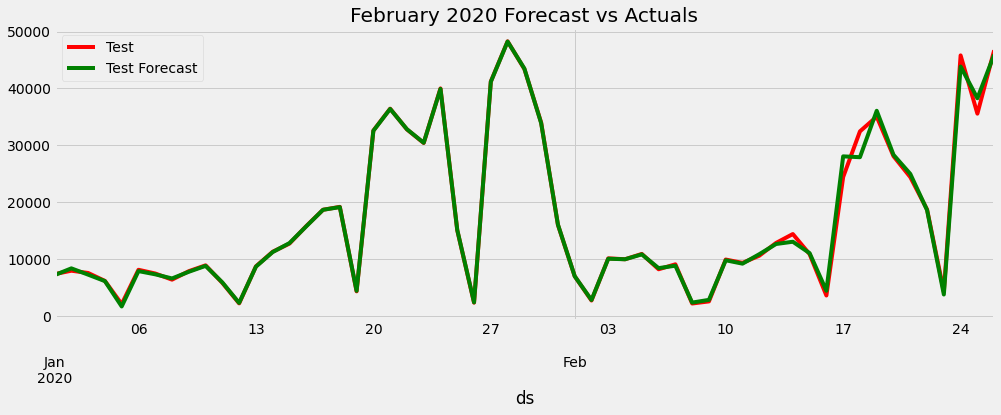

In [48]:
# Compare the Sales and forecasted Sales
fig, ax = plt.subplots(1, figsize = (15, 5))
X_test.plot(kind = "line", x = "ds", y = "y", color = "red", label = "Test", ax = ax)
X_test_final.plot(kind = "line", x = "ds", y = "yhat", color = "green", label = "Test Forecast", ax = ax)
plt.title("February 2020 Forecast vs Actuals")
plt.show()

In [49]:
# Model performance on X_test
mape = mean_absolute_percentage_error(X_test["y"], X_test_final["yhat"])
print("MAPE:%s" % round(mape, 4))

MAPE:3.2443
